In [ ]:
!pip install tensorflow
!pip install keras
!pip install matplotlib
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import shutil
import zipfile
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
ZIP_PATH = "/content/drive/MyDrive/fruits_vege.zip"
LOCAL_ZIP = "/content/data.zip"
EXTRACT_DIR = "/content"

shutil.copy(ZIP_PATH, LOCAL_ZIP)

with zipfile.ZipFile(LOCAL_ZIP, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Done extracting")
print(os.listdir("/content"))


Done extracting
['.config', 'validation', 'train', 'drive', 'data.zip', 'test', 'sample_data']


In [4]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Configuration

In [7]:
# =========================
# CONFIG
# =========================
DATASET_ROOT = "/content"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "validation")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

IMG_SIZE = (128, 128)
BATCH_SIZE = 16
SEED = 123

HEAD_EPOCHS = 8
FINETUNE_EPOCHS = 10
UNFREEZE_LAST_N = 20   #20 or 30

for p in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(p, "->", os.path.exists(p))

/content/train -> True
/content/validation -> True
/content/test -> True


Read Data with API

`image_dataset_from_directory`:
- đọc nhãn từ tên thư mục con
- trả về `tf.data.Dataset`
- dễ kết hợp với `cache()` / `prefetch()`

Dataset Description

The dataset is organized into training, validation, and test subsets. Each subfolder represents one plant class. This structure allows the model to learn from the training set, tune performance using the validation set, and evaluate generalization on unseen test images.

In [33]:
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 3115 files belonging to 36 classes.
Found 351 files belonging to 36 classes.
Found 359 files belonging to 36 classes.
Classes: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']
Number of classes: 36


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [12]:
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

train_counts = {}
for cls in class_names:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    train_counts[cls] = sum(
        1 for f in os.listdir(cls_dir)
        if f.lower().endswith(IMAGE_EXTS)
    )

print("Train counts by class:")
for k, v in train_counts.items():
    print(f"  {k}: {v}")

total_train = sum(train_counts.values())
class_weight = {
    idx: total_train / (num_classes * train_counts[cls])
    for idx, cls in enumerate(class_names)
}

print("\nClass weight:")
for idx, w in class_weight.items():
    print(f"  {class_names[idx]} ({idx}): {w:.4f}")

Train counts by class:
  apple: 68
  banana: 75
  beetroot: 88
  bell pepper: 90
  cabbage: 92
  capsicum: 89
  carrot: 82
  cauliflower: 79
  chilli pepper: 87
  corn: 87
  cucumber: 94
  eggplant: 84
  garlic: 92
  ginger: 68
  grapes: 100
  jalepeno: 88
  kiwi: 88
  lemon: 82
  lettuce: 97
  mango: 86
  onion: 94
  orange: 69
  paprika: 83
  pear: 89
  peas: 100
  pineapple: 99
  pomegranate: 79
  potato: 77
  raddish: 81
  soy beans: 97
  spinach: 97
  sweetcorn: 91
  sweetpotato: 69
  tomato: 92
  turnip: 98
  watermelon: 84

Class weight:
  apple (0): 1.2725
  banana (1): 1.1537
  beetroot (2): 0.9833
  bell pepper (3): 0.9614
  cabbage (4): 0.9405
  capsicum (5): 0.9722
  carrot (6): 1.0552
  cauliflower (7): 1.0953
  chilli pepper (8): 0.9946
  corn (9): 0.9946
  cucumber (10): 0.9205
  eggplant (11): 1.0301
  garlic (12): 0.9405
  ginger (13): 1.2725
  grapes (14): 0.8653
  jalepeno (15): 0.9833
  kiwi (16): 0.9833
  lemon (17): 1.0552
  lettuce (18): 0.8920
  mango (19): 1.00

Sample Picture

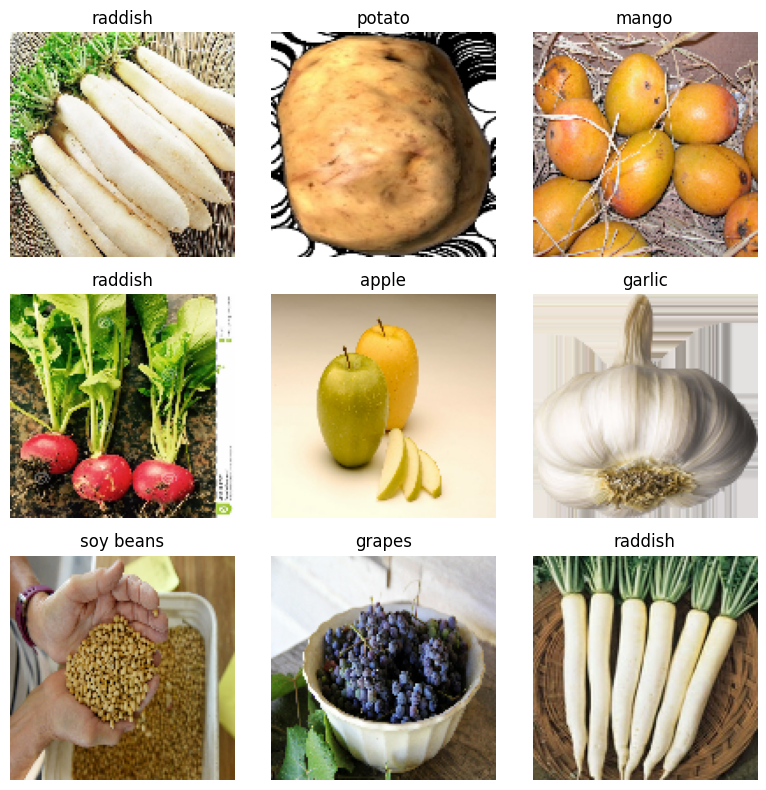

In [13]:
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()

Data augmentation

Keep augmentation lightweight to:

- avoid making the model harder to train
- still help reduce overfitting on a small dataset

In [15]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
    ],
    name="data_augmentation",
)

Model **MobileNetV3Small**

In [16]:
base_model = keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
    include_preprocessing=True,
)

base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 36)             │        20,772 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 959,892 (3.66 MB)

 Trainable params: 20,772 (81.14 KB)

 Non-trainable params: 939,120 (3.58 MB)

Train classifier head

In [17]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
    keras.callbacks.ModelCheckpoint(
        "best_model_phase1.keras",
        monitor="val_accuracy",
        save_best_only=True,
    ),
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 74s 312ms/step - accuracy: 0.2748 - loss: 2.7215 - val_accuracy: 0.7151 - val_loss: 1.2271 - learning_rate: 0.0010
Epoch 2/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5592 - loss: 1.5915 - val_accuracy: 0.7835 - val_loss: 0.7943 - learning_rate: 0.0010
Epoch 3/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6366 - loss: 1.2808 - val_accuracy: 0.8234 - val_loss: 0.6522 - learning_rate: 0.0010
Epoch 4/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6783 - loss: 1.1091 - val_accuracy: 0.8604 - val_loss: 0.5608 - learning_rate: 0.0010
Epoch 5/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7162 - loss: 0.9996 - val_accuracy: 0.8775 - val_loss: 0.5155 - learning_rate: 0.0010
Epoch 6/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7226 - loss: 0.9318 - val_accuracy: 0.8746 - val_loss: 0.4859 - learning_rate: 0.0010
Epoch 7/8
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7390 - loss: 0.8748

Fine-tune Layer

**`UNFREEZE_LAST_N`**

In [19]:
base_model.trainable = True

for layer in base_model.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 36)             │        20,772 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 959,892 (3.66 MB)

 Trainable params: 371,508 (1.42 MB)

 Non-trainable params: 588,384 (2.24 MB)

In [20]:
callbacks_finetune = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
    ),
    keras.callbacks.ModelCheckpoint(
        "best_model_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True,
    ),
]

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks_finetune,
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.6331 - loss: 1.2309 - val_accuracy: 0.8974 - val_loss: 0.4073 - learning_rate: 1.0000e-05
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6446 - loss: 1.1770 - val_accuracy: 0.8917 - val_loss: 0.4066 - learning_rate: 1.0000e-05
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6578 - loss: 1.1129 - val_accuracy: 0.8889 - val_loss: 0.4113 - learning_rate: 1.0000e-05
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6687 - loss: 1.0879 - val_accuracy: 0.8946 - val_loss: 0.4162 - learning_rate: 1.0000e-05
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6735 - loss: 1.0759 - val_accuracy: 0.8917 - val_loss: 0.4232 - learning_rate: 5.0000e-06


Figure train

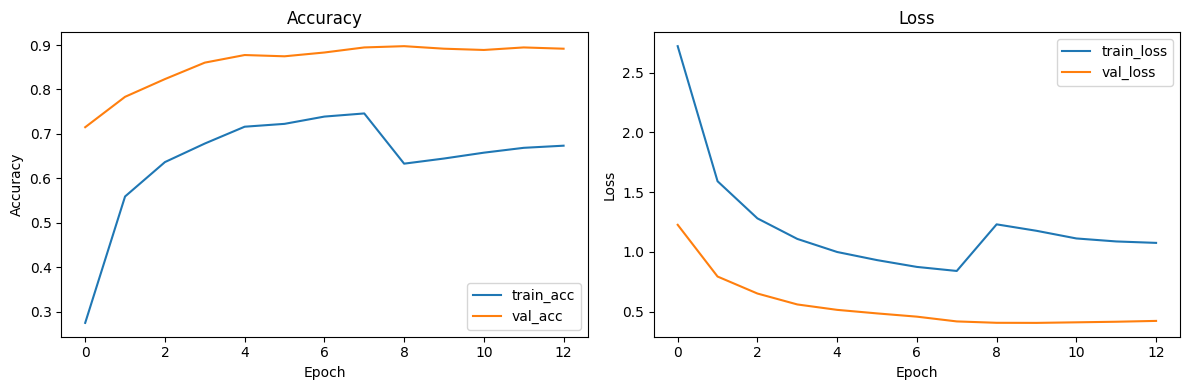

In [21]:
def combine_history(hist1, hist2, key):
    return hist1.history.get(key, []) + hist2.history.get(key, [])

acc = combine_history(history_head, history_finetune, "accuracy")
val_acc = combine_history(history_head, history_finetune, "val_accuracy")
loss = combine_history(history_head, history_finetune, "loss")
val_loss = combine_history(history_head, history_finetune, "val_loss")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label="train_acc")
plt.plot(val_acc, label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Validation with Test Set

In [22]:
best_model = keras.models.load_model("best_model_finetuned.keras")

test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print("Test loss:", round(float(test_loss), 4))
print("Test accuracy:", round(float(test_acc), 4))

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 970us/step - accuracy: 0.6875 - loss: 1.0201
Test loss: 1.0201
Test accuracy: 0.6875


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Classification report + confusion matrix

In [34]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

y_true = []
y_pred = []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Total test samples:", len(y_true))

print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

Total test samples: 359
Accuracy : 0.8886
Precision: 0.8971
Recall   : 0.8886
F1-score : 0.8883

Classification Report:
               precision    recall  f1-score   support

        apple     0.7500    0.6000    0.6667        10
       banana     0.7778    0.7778    0.7778         9
     beetroot     0.9091    1.0000    0.9524        10
  bell pepper     0.6667    0.6000    0.6316        10
      cabbage     1.0000    1.0000    1.0000        10
     capsicum     0.5714    0.8000    0.6667        10
       carrot     1.0000    1.0000    1.0000        10
  cauliflower     1.0000    1.0000    1.0000        10
chilli pepper     0.6667    0.6000    0.6316        10
         corn     0.8750    0.7000    0.7778        10
     cucumber     0.7143    1.0000    0.8333        10
     eggplant     1.0000    0.9000    0.9474        10
       garlic     1.0000    1.0000    1.0000        10
       ginger     1.0000    1.0000    1.0000        10
       grapes     1.0000    0.9000    0.9474        10

Error Analysis

The confusion matrix is used to analyze which plant classes are most frequently confused by the model. Misclassification usually occurs between plant species that have visually similar leaf shapes, colors, or textures.

The top error pairs are listed below to identify classes that may require more training images, better image quality, or stronger augmentation.

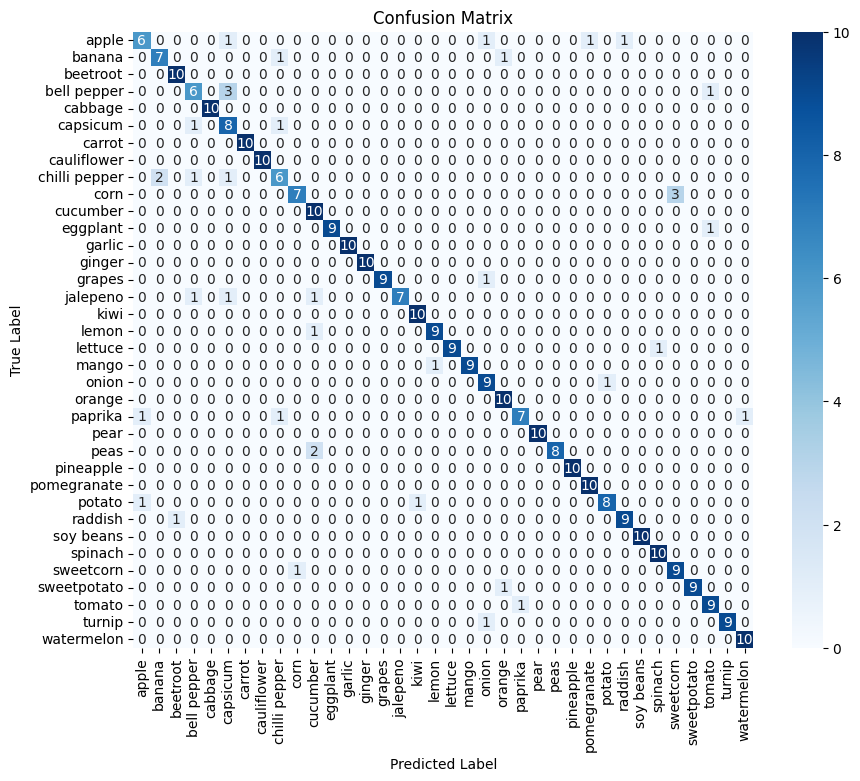

In [37]:
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)

errors = []

for true_idx in range(len(class_names)):
    for pred_idx in range(len(class_names)):
        if true_idx != pred_idx and cm[true_idx][pred_idx] > 0:
            errors.append({
                "true_class": class_names[true_idx],
                "predicted_class": class_names[pred_idx],
                "num_errors": cm[true_idx][pred_idx]
            })

error_df = pd.DataFrame(errors).sort_values(by="num_errors", ascending=False)
error_df.head(10)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Save Model & Class Name

In [ ]:
best_model.save("fruit_veg_mobilenetv3small_finetuned.keras")

with open("class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False)

print("Saved:")
print(" - fruit_veg_mobilenetv3small_finetuned.keras")
print(" - class_names.json")

Saved:
 - fruit_veg_mobilenetv3small_finetuned.keras
 - class_names.json


Test Model with Random Picture

In [ ]:
def predict_image(image_path, model, class_names, img_size=IMG_SIZE, top_k=4):
    img = keras.utils.load_img(image_path, target_size=img_size)
    img_array = keras.utils.img_to_array(img)
    img_batch = tf.expand_dims(img_array, axis=0)

    probs = model.predict(img_batch, verbose=0)[0]
    pred_idx = int(np.argmax(probs))

    plt.figure(figsize=(4, 4))
    plt.imshow(img_array.astype("uint8"))
    plt.title(f"Predicted: {class_names[pred_idx]} ({probs[pred_idx]:.4f})")
    plt.axis("off")
    plt.show()

    top_indices = np.argsort(probs)[::-1][:top_k]
    print("Top predictions:")
    for idx in top_indices:
        print(f"  {class_names[idx]:12s}: {probs[idx]:.4f}")

    return class_names[pred_idx], float(probs[pred_idx]), probs

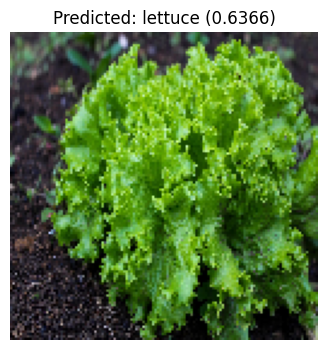

Top predictions:
  lettuce     : 0.6366
  peas        : 0.0937
  grapes      : 0.0673
  soy beans   : 0.0461


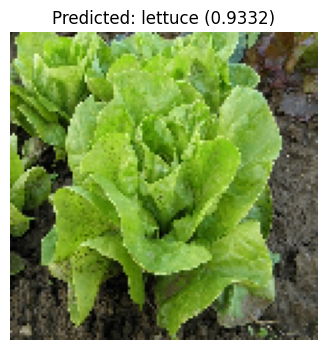

Top predictions:
  lettuce     : 0.9332
  spinach     : 0.0498
  cabbage     : 0.0057
  turnip      : 0.0026


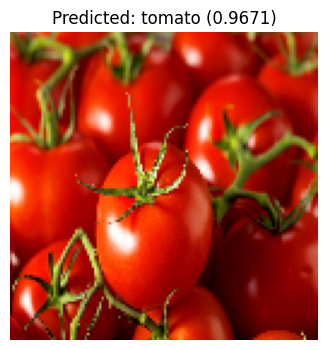

Top predictions:
  tomato      : 0.9671
  apple       : 0.0104
  pomegranate : 0.0095
  capsicum    : 0.0051


('tomato',
 0.9670804738998413,
 array([1.0441177e-02, 2.0234638e-07, 2.2102000e-05, 2.2666974e-03,
        8.0049650e-10, 5.0552534e-03, 1.6257245e-06, 7.5675377e-10,
        9.1195834e-05, 2.7619633e-08, 1.3047692e-07, 2.1598709e-04,
        8.0738960e-07, 3.9017291e-08, 3.9074101e-07, 9.0848713e-05,
        2.8092185e-05, 3.5862618e-06, 1.3956847e-09, 1.7433531e-04,
        1.7596632e-03, 9.4590313e-04, 2.1832958e-03, 4.2621494e-05,
        1.4069420e-06, 1.5176660e-08, 9.4856275e-03, 1.8664814e-06,
        9.4555595e-05, 2.9629425e-06, 3.6541228e-09, 2.0411395e-09,
        1.5535868e-06, 9.6708047e-01, 5.3710369e-06, 2.0861105e-06],
       dtype=float32))

In [ ]:
image_path = "/content/lettuce1.jpg"
predict_image(image_path, best_model, class_names)

image_path = "/content/lettuce2.jpg"
predict_image(image_path, best_model, class_names)

image_path = "/content/tomato1.jpg"
predict_image(image_path, best_model, class_names)